# Taller PLN

Notebook orquestador para el taller de datasets, tokenizacion, embeddings distribucionales, procesamiento de PDFs y embeddings semanticos.

## Configuracion local

Esta celda permite importar los modulos del proyecto cuando el notebook se ejecuta desde `notebooks/` o desde la raiz del proyecto.

In [21]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import config

config.PROJECT_ROOT

PosixPath('/Users/lau/Desktop/Universidad/PLN/taller_2_pln')

## Bloque 1: Tokenizacion de datasets

### 1.1 Imports del bloque

In [22]:
import pandas as pd

### 1.2 Carga local de datasets

Conll2002 se lee desde archivos locales ya separados en train, validation/dev y test. Ancora se lee desde CSV y luego se divide manualmente en 70/15/15.

In [23]:
conll2002_splits = load_conll2002_local()

ancora_sentences = load_ancora_local()
ancora_splits = split_ancora_70_15_15(ancora_sentences)

conll2002_examples = get_first_sentences_by_split(conll2002_splits, n=3)
ancora_examples = get_first_sentences_by_split(ancora_splits, n=3)

[Conll2002] Archivos encontrados en /Users/lau/Desktop/Universidad/PLN/taller_2_pln/data/raw/conll2002:
  - test.txt
  - train.txt
  - valid.txt
[Conll2002] train: 8323 sentencias cargadas desde train.txt
[Conll2002] validation: 1915 sentencias cargadas desde valid.txt
[Conll2002] test: 1517 sentencias cargadas desde test.txt
[Ancora] Archivos encontrados en /Users/lau/Desktop/Universidad/PLN/taller_2_pln/data/raw/ancora:
  - ancora.csv
[Ancora] Columnas disponibles de ancora.csv: ['Unnamed: 0', 'Sentence #', 'Word', 'Tag', 'POS']
[Ancora] Primeras 5 filas:
 Unnamed: 0  Sentence #     Word Tag   POS
          0           0      Las   O   DET
          1           0 reservas   O  NOUN
          2           0       de   O   ADP
          3           0      oro   O  NOUN
          4           0        y   O CCONJ
[Ancora] 17345 sentencias cargadas desde ancora.csv
[Ancora] Split 70/15/15: train=12141, validation=2601, test=2603
[train] 3 sentencias usadas para comparacion
[validation] 3 s

### 1.3 Primeras sentencias originales

Antes de tokenizar, revisamos las tres primeras sentencias de cada split. Esto ayuda a verificar que los tokens leídos desde los archivos locales se agruparon correctamente en oraciones.

In [24]:
def examples_to_dataframe(dataset_name, examples_by_split):
    rows = []
    for split_name, examples in examples_by_split.items():
        for sentence_index, example in enumerate(examples, start=1):
            tokens = example["tokens"]
            rows.append(
                {
                    "dataset": dataset_name,
                    "split": split_name,
                    "indice_sentencia": sentence_index,
                    "tokens_originales": tokens,
                    "texto_reconstruido": reconstruct_text_from_tokens(tokens),
                    "n_tokens_originales": len(tokens),
                }
            )
    return pd.DataFrame(rows)


original_examples_df = pd.concat(
    [
        examples_to_dataframe("conll2002", conll2002_examples),
        examples_to_dataframe("ancora", ancora_examples),
    ],
    ignore_index=True,
)

original_examples_df

,dataset,split,indice_sentencia,tokens_originales,texto_reconstruido,n_tokens_originales
0,conll2002,train,1,"[Melbourne, (, Australia, ), ,, 25, may, (, EFE, ), .]","Melbourne (Australia), 25 may (EFE).",11
1,conll2002,train,2,[-],-,1
2,conll2002,train,3,"[El, Abogado, General, del, Estado, ,, Daryl, Williams, ,, subrayó, hoy, la, necesidad, de, tomar, medidas, para, proteger, al, sistema, judicial, australia...","El Abogado General del Estado, Daryl Williams, subrayó hoy la necesidad de tomar medidas para proteger al sistema judicial australiano frente a una página d...",40
3,conll2002,validation,1,"[Sao, Paulo, (, Brasil, ), ,, 23, may, (, EFECOM, ), .]","Sao Paulo (Brasil), 23 may (EFECOM).",12
4,conll2002,validation,2,[-],-,1
5,conll2002,validation,3,"[La, multinacional, española, Telefónica, ha, impuesto, un, récord, mundial, al, poner, en, servicio, tres, millones, de, nuevas, líneas, en, el, estado, br...",La multinacional española Telefónica ha impuesto un récord mundial al poner en servicio tres millones de nuevas líneas en el estado brasileño de Sao Paulo d...,51
6,conll2002,test,1,"[La, Coruña, ,, 23, may, (, EFECOM, ), .]","La Coruña, 23 may (EFECOM).",9
7,conll2002,test,2,[-],-,1
8,conll2002,test,3,"[Las, reservas, "", on, line, "", de, billetes, aéreos, a, través, de, Internet, aumentaron, en, España, un, 300, por, ciento, en, el, primer, trimestre, de, ...","Las reservas "" on line "" de billetes aéreos a través de Internet aumentaron en España un 300 por ciento en el primer trimestre de este año con respecto al m...",48
9,ancora,train,1,"[El, vuelacercas, de, Bagwell, ,, el, octavo, de, la, temporada, ,, fue, conectado, en, el, episodio, inicial, ,, y, el, de, Hidalgo, y, Ward, ,, el, quinto...","El vuelacercas de Bagwell, el octavo de la temporada, fue conectado en el episodio inicial, y el de Hidalgo y Ward, el quinto para ambos, fueron despachados...",37


### 1.4 Cargar tokenizadores

BETO usa WordPiece. T5 usa SentencePiece.

In [25]:
beto_tokenizer = load_wordpiece_tokenizer()
t5_tokenizer = load_sentencepiece_tokenizer()

### 1.5 Inspeccion de una sentencia

Cambia `dataset_name`, `split_name` y `sentence_position` para mirar otros casos. Esta celda muestra el paso de tokens originales a subtokens.

In [26]:
dataset_name = "conll2002"
split_name = "train"
sentence_position = 0

examples_lookup = {
    "conll2002": conll2002_examples,
    "ancora": ancora_examples,
}

selected_example = examples_lookup[dataset_name][split_name][sentence_position]
selected_tokens = selected_example["tokens"]
selected_text = reconstruct_text_from_tokens(selected_tokens)

selected_beto = tokenize_with_beto([selected_text], tokenizer=beto_tokenizer)[0]
selected_t5 = tokenize_with_t5([selected_text], tokenizer=t5_tokenizer)[0]

print("Dataset:", dataset_name)
print("Split:", split_name)
print("Indice:", sentence_position + 1)
print("\nTokens originales:")
print(selected_tokens)
print("\nTexto reconstruido:")
print(selected_text)
print("\nWordPiece-BETO:")
print(selected_beto["tokens"])
print("\nSentencePiece-T5:")
print(selected_t5["tokens"])

Dataset: conll2002
Split: train
Indice: 1

Tokens originales:
['Melbourne', '(', 'Australia', ')', ',', '25', 'may', '(', 'EFE', ')', '.']

Texto reconstruido:
Melbourne (Australia), 25 may (EFE).

WordPiece-BETO:
['[CLS]', 'Mel', '##bourne', '(', 'Australia', ')', ',', '25', 'may', '(', 'EF', '##E', ')', '.', '[SEP]']

SentencePiece-T5:
['▁Melbourne', '▁(', 'Australia', '),', '▁25', '▁may', '▁(', 'E', 'FE', ').', '</s>']


### 1.6 Tabla comparativa

La razon de fragmentacion compara cuantos subtokens genera cada tokenizador frente a la cantidad de tokens originales. Valores mayores indican mas division en subtokens.

In [27]:
conll_comparison_df = build_tokenization_comparison_dataframe(
    "conll2002",
    conll2002_examples,
    beto_tokenizer=beto_tokenizer,
    t5_tokenizer=t5_tokenizer,
)
ancora_comparison_df = build_tokenization_comparison_dataframe(
    "ancora",
    ancora_examples,
    beto_tokenizer=beto_tokenizer,
    t5_tokenizer=t5_tokenizer,
)

comparison_df = pd.concat([conll_comparison_df, ancora_comparison_df], ignore_index=True)
comparison_df = comparison_df.rename(
    columns={
        "example_index": "indice_sentencia",
        "text": "texto_reconstruido",
        "original_tokens": "tokens_originales",
        "beto_tokens": "tokens_wordpiece_beto",
        "t5_tokens": "tokens_sentencepiece_t5",
    }
)
comparison_df["n_tokens_originales"] = comparison_df["tokens_originales"].apply(len)
comparison_df["n_subtokens_wordpiece"] = comparison_df["tokens_wordpiece_beto"].apply(len)
comparison_df["n_subtokens_sentencepiece"] = comparison_df["tokens_sentencepiece_t5"].apply(len)
comparison_df["razon_fragmentacion_wordpiece"] = (
    comparison_df["n_subtokens_wordpiece"] / comparison_df["n_tokens_originales"]
).round(2)
comparison_df["razon_fragmentacion_sentencepiece"] = (
    comparison_df["n_subtokens_sentencepiece"] / comparison_df["n_tokens_originales"]
).round(2)

columns = [
    "dataset",
    "split",
    "indice_sentencia",
    "tokens_originales",
    "texto_reconstruido",
    "tokens_wordpiece_beto",
    "tokens_sentencepiece_t5",
    "n_tokens_originales",
    "n_subtokens_wordpiece",
    "n_subtokens_sentencepiece",
    "razon_fragmentacion_wordpiece",
    "razon_fragmentacion_sentencepiece",
]
comparison_df = comparison_df[columns]
comparison_df

,dataset,split,indice_sentencia,tokens_originales,texto_reconstruido,tokens_wordpiece_beto,tokens_sentencepiece_t5,n_tokens_originales,n_subtokens_wordpiece,n_subtokens_sentencepiece,razon_fragmentacion_wordpiece,razon_fragmentacion_sentencepiece
0,conll2002,train,1,"[Melbourne, (, Australia, ), ,, 25, may, (, EFE, ), .]","Melbourne (Australia), 25 may (EFE).","[[CLS], Mel, ##bourne, (, Australia, ), ,, 25, may, (, EF, ##E, ), ., [SEP]]","[▁Melbourne, ▁(, Australia, ),, ▁25, ▁may, ▁(, E, FE, )., </s>]",11,15,11,1.36,1.00
1,conll2002,train,2,[-],-,"[[CLS], -, [SEP]]","[▁, -, </s>]",1,3,3,3.00,3.00
2,conll2002,train,3,"[El, Abogado, General, del, Estado, ,, Daryl, Williams, ,, subrayó, hoy, la, necesidad, de, tomar, medidas, para, proteger, al, sistema, judicial, australia...","El Abogado General del Estado, Daryl Williams, subrayó hoy la necesidad de tomar medidas para proteger al sistema judicial australiano frente a una página d...","[[CLS], El, Abogado, General, del, Estado, ,, Dar, ##yl, W, ##illiams, ,, subrayó, hoy, la, necesidad, de, tomar, medidas, para, proteger, al, sistema, judi...","[▁El, ▁Ab, oga, d, o, ▁General, ▁de, l, ▁Est, a, d, o, ,, ▁Da, ryl, ▁Williams, ,, ▁sub, ray, ó, ▁ho, y, ▁la, ▁nec, e, s, idad, ▁de, ▁to, mar, ▁, medi, das, ...",40,46,87,1.15,2.17
3,conll2002,validation,1,"[Sao, Paulo, (, Brasil, ), ,, 23, may, (, EFECOM, ), .]","Sao Paulo (Brasil), 23 may (EFECOM).","[[CLS], Sa, ##o, Paulo, (, Brasil, ), ,, 23, may, (, EF, ##EC, ##OM, ), ., [SEP]]","[▁Sa, o, ▁Paul, o, ▁(, Bra, s, il, ),, ▁23, ▁may, ▁(, E, FE, COM, )., </s>]",12,17,17,1.42,1.42
4,conll2002,validation,2,[-],-,"[[CLS], -, [SEP]]","[▁, -, </s>]",1,3,3,3.00,3.00
5,conll2002,validation,3,"[La, multinacional, española, Telefónica, ha, impuesto, un, récord, mundial, al, poner, en, servicio, tres, millones, de, nuevas, líneas, en, el, estado, br...",La multinacional española Telefónica ha impuesto un récord mundial al poner en servicio tres millones de nuevas líneas en el estado brasileño de Sao Paulo d...,"[[CLS], La, multinacional, española, Tele, ##fónica, ha, impuesto, un, récord, mundial, al, poner, en, servicio, tres, millones, de, nuevas, líneas, en, el,...","[▁La, ▁multi, nac, ional, ▁esp, a, <unk>, o, la, ▁Tele, f, ón, ica, ▁ha, ▁imp, u, est, o, ▁un, ▁ré, cord, ▁mun, dial, ▁al, ▁po, ner, ▁, en, ▁, serv, ici, o,...",51,62,122,1.22,2.39
6,conll2002,test,1,"[La, Coruña, ,, 23, may, (, EFECOM, ), .]","La Coruña, 23 may (EFECOM).","[[CLS], La, Coruña, ,, 23, may, (, EF, ##EC, ##OM, ), ., [SEP]]","[▁La, ▁Cor, u, <unk>, a, ,, ▁23, ▁may, ▁(, E, FE, COM, )., </s>]",9,13,14,1.44,1.56
7,conll2002,test,2,[-],-,"[[CLS], -, [SEP]]","[▁, -, </s>]",1,3,3,3.00,3.00
8,conll2002,test,3,"[Las, reservas, "", on, line, "", de, billetes, aéreos, a, través, de, Internet, aumentaron, en, España, un, 300, por, ciento, en, el, primer, trimestre, de, ...","Las reservas "" on line "" de billetes aéreos a través de Internet aumentaron en España un 300 por ciento en el primer trimestre de este año con respecto al m...","[[CLS], Las, reservas, "", on, line, "", de, billetes, aéreos, a, través, de, Internet, aumentaron, en, España, un, 300, por, ciento, en, el, primer, trimestr...","[▁Las, ▁, re, serv, a, s, ▁"", ▁on, ▁line, ▁"", ▁de, ▁billet, e, s, ▁, a, é, re, o, s, ▁, a, ▁, tra, vé, s, ▁de, ▁Internet, ▁au, ment, ar, on, ▁, en, ▁Espa, <...",48,56,103,1.17,2.15
9,ancora,train,1,"[El, vuelacercas, de, Bagwell, ,, el, octavo, de, la, temporada, ,, fue, conectado, en, el, episodio, inicial, ,, y, el, de, Hidalgo, y, Ward, ,, el, quinto...","El vuelacercas de Bagwell, el octavo de la temporada, fue conectado en el episodio inicial, y el de Hidalgo y Ward, el quinto para ambos, fueron despachados...","[[CLS], El, vuela, ##cer, ##cas, de, Bag, ##w, ##ell, ,, el, octavo, de, la, temporada, ,, fue, conectado, en, el, episodio, inicial, ,, y, el, de, Hidalgo,...","[▁El, ▁vue, lac, er, cas, ▁de, ▁Bag, well, ,, ▁, e, l, ▁, o, c, t, a, vo, ▁de, ▁la, ▁, tempo, rada, ,, ▁fu, e, ▁co

### 1.7 Inspeccionar una fila

Esta funcion muestra una fila de forma legible para analizar caso por caso sin perderse en una tabla ancha.

In [28]:
def inspect_tokenization_row(dataframe, row_index):
    row = dataframe.iloc[row_index]
    print(f"Dataset: {row['dataset']}")
    print(f"Split: {row['split']}")
    print(f"Indice de sentencia: {row['indice_sentencia']}")
    print("\nTexto reconstruido:")
    print(row["texto_reconstruido"])
    print("\nTokens originales:")
    print(row["tokens_originales"])
    print("\nWordPiece-BETO:")
    print(row["tokens_wordpiece_beto"])
    print("\nSentencePiece-T5:")
    print(row["tokens_sentencepiece_t5"])
    print("\nConteos:")
    print(
        f"originales={row['n_tokens_originales']}, "
        f"wordpiece={row['n_subtokens_wordpiece']}, "
        f"sentencepiece={row['n_subtokens_sentencepiece']}"
    )
    print("\nRazones de fragmentacion:")
    print(
        f"wordpiece={row['razon_fragmentacion_wordpiece']}, "
        f"sentencepiece={row['razon_fragmentacion_sentencepiece']}"
    )


inspect_tokenization_row(comparison_df, row_index=0)

Dataset: conll2002
Split: train
Indice de sentencia: 1

Texto reconstruido:
Melbourne (Australia), 25 may (EFE).

Tokens originales:
['Melbourne', '(', 'Australia', ')', ',', '25', 'may', '(', 'EFE', ')', '.']

WordPiece-BETO:
['[CLS]', 'Mel', '##bourne', '(', 'Australia', ')', ',', '25', 'may', '(', 'EF', '##E', ')', '.', '[SEP]']

SentencePiece-T5:
['▁Melbourne', '▁(', 'Australia', '),', '▁25', '▁may', '▁(', 'E', 'FE', ').', '</s>']

Conteos:
originales=11, wordpiece=15, sentencepiece=11

Razones de fragmentacion:
wordpiece=1.36, sentencepiece=1.0


### 1.8 Fragmentacion en WordPiece

En WordPiece, el prefijo `##` indica que el subtoken continua una palabra anterior. Esto permite detectar palabras que fueron partidas.

In [29]:
def wordpiece_continuation_tokens(tokens):
    return [token for token in tokens if token.startswith("##")]


wordpiece_fragmentation_df = comparison_df[["dataset", "split", "indice_sentencia"]].copy()
wordpiece_fragmentation_df["subtokens_con_prefijo_##"] = comparison_df[
    "tokens_wordpiece_beto"
].apply(wordpiece_continuation_tokens)
wordpiece_fragmentation_df["n_continuaciones_wordpiece"] = wordpiece_fragmentation_df[
    "subtokens_con_prefijo_##"
].apply(len)

wordpiece_fragmentation_df.sort_values("n_continuaciones_wordpiece", ascending=False)

,dataset,split,indice_sentencia,subtokens_con_prefijo_##,n_continuaciones_wordpiece
12,ancora,validation,1,"[##dos, ##bera, ##n, ##mente, ##en, ##den, ##fonía, ##mente, ##il, ##ms]",10
5,conll2002,validation,3,"[##fónica, ##o, ##a, ##s, ##p, ##fónica, ##avier, ##ei, ##ra]",9
16,ancora,test,2,"[##ría, ##guera, ##s, ##w, ##en, ##mb, ##y, ##7]",8
10,ancora,train,2,"[##s, ##sa, ##lo, ##r, ##lo, ##da, ##s]",7
13,ancora,validation,2,"[##illa, ##ano, ##s, ##da, ##mante, ##7, ##8]",7
9,ancora,train,1,"[##cer, ##cas, ##w, ##ell, ##ard, ##chados]",6
8,conll2002,test,3,"[##ñ, ##igo, ##da, ##ia, ##de, ##us]",6
14,ancora,validation,3,"[##cal, ##eras, ##a, ##oman, ##ías]",5
2,conll2002,train,3,"[##yl, ##illiams, ##bili, ##ta]",4
17,ancora,test,3,"[##s, ##udo, ##do]",3


### 1.9 Marca de espacio en SentencePiece

En SentencePiece, muchos tokens empiezan con `▁`. Esa marca representa un espacio o inicio de unidad, y ayuda al modelo a saber donde comienzan segmentos de texto.

In [30]:
def sentencepiece_boundary_tokens(tokens):
    return [token for token in tokens if token.startswith("▁")]


sentencepiece_boundary_df = comparison_df[["dataset", "split", "indice_sentencia"]].copy()
sentencepiece_boundary_df["tokens_con_prefijo_▁"] = comparison_df[
    "tokens_sentencepiece_t5"
].apply(sentencepiece_boundary_tokens)
sentencepiece_boundary_df["n_marcas_sentencepiece"] = sentencepiece_boundary_df[
    "tokens_con_prefijo_▁"
].apply(len)

sentencepiece_boundary_df

,dataset,split,indice_sentencia,tokens_con_prefijo_▁,n_marcas_sentencepiece
0,conll2002,train,1,"[▁Melbourne, ▁(, ▁25, ▁may, ▁(]",5
1,conll2002,train,2,[▁],1
2,conll2002,train,3,"[▁El, ▁Ab, ▁General, ▁de, ▁Est, ▁Da, ▁Williams, ▁sub, ▁ho, ▁la, ▁nec, ▁de, ▁to, ▁, ▁para, ▁prote, ▁al, ▁sistem, ▁, ▁australia, ▁fr, ▁, ▁un, ▁, ▁de, ▁interne...",37
3,conll2002,validation,1,"[▁Sa, ▁Paul, ▁(, ▁23, ▁may, ▁(]",6
4,conll2002,validation,2,[▁],1
5,conll2002,validation,3,"[▁La, ▁multi, ▁esp, ▁Tele, ▁ha, ▁imp, ▁un, ▁ré, ▁mun, ▁al, ▁po, ▁, ▁, ▁, ▁mill, ▁de, ▁nu, ▁, ▁, ▁, ▁est, ▁bra, ▁de, ▁Sa, ▁Paul, ▁des, ▁que, ▁as, ▁, ▁control...",48
6,conll2002,test,1,"[▁La, ▁Cor, ▁23, ▁may, ▁(]",5
7,conll2002,test,2,[▁],1
8,conll2002,test,3,"[▁Las, ▁, ▁"", ▁on, ▁line, ▁"", ▁de, ▁billet, ▁, ▁, ▁, ▁de, ▁Internet, ▁au, ▁, ▁Espa, ▁un, ▁300, ▁por, ▁, ▁, ▁, ▁primer, ▁trimestre, ▁de, ▁este, ▁, ▁con, ▁res...",45
9,ancora,train,1,"[▁El, ▁vue, ▁de, ▁Bag, ▁, ▁, ▁de, ▁la, ▁, ▁fu, ▁conecta, ▁, ▁, ▁episod, ▁in, ▁, ▁, ▁de, ▁Hi, ▁, ▁Ward, ▁, ▁qui, ▁para, ▁, ▁fu, ▁des, ▁, ▁la, ▁se, ▁]",31


## Análisis interpretativo de la tokenización

Esta sección trabaja sobre los CSV enriquecidos generados por `scripts/analyze_tokenization.py`. La idea es separar fragmentación real, tokens especiales, desconocidos y marcas propias de cada tokenizador.

### Cargar análisis enriquecido

Primero ejecuta `python scripts/run_tokenization.py` y luego `python scripts/analyze_tokenization.py`. Después, esta celda carga los resultados listos para inspección.

In [31]:
import pandas as pd

from src.config import OUTPUTS_DIR, FIGURES_DIR
from src.visualization import plot_fragmentation_ratios, plot_unknown_counts

tokenization_output_dir = OUTPUTS_DIR / "tokenization"

enriched_df = pd.read_csv(tokenization_output_dir / "tokenization_enriched_analysis.csv")
summary_global_df = pd.read_csv(tokenization_output_dir / "tokenization_summary_global.csv")
summary_by_dataset_df = pd.read_csv(tokenization_output_dir / "tokenization_summary_by_dataset.csv")
most_fragmented_wordpiece_df = pd.read_csv(tokenization_output_dir / "most_fragmented_wordpiece.csv")
most_fragmented_sentencepiece_df = pd.read_csv(tokenization_output_dir / "most_fragmented_sentencepiece.csv")

enriched_df.shape


(18, 31)

### Métricas por sentencia

Para comparar fragmentación léxica, conviene excluir tokens especiales como `[CLS]`, `[SEP]` y `</s>`. Esos tokens son agregados por el modelo, no vienen de las palabras originales.

In [32]:
analysis_columns = [
    "dataset",
    "split",
    "indice_sentencia",
    "n_tokens_originales",
    "n_subtokens_wordpiece_sin_especiales",
    "n_subtokens_sentencepiece_sin_especiales",
    "razon_fragmentacion_wordpiece_sin_especiales",
    "razon_fragmentacion_sentencepiece_sin_especiales",
    "n_unknown_sentencepiece",
    "n_continuaciones_wordpiece",
    "tokenizador_menos_fragmentado",
]

enriched_df[analysis_columns]


,dataset,split,indice_sentencia,n_tokens_originales,n_subtokens_wordpiece_sin_especiales,n_subtokens_sentencepiece_sin_especiales,razon_fragmentacion_wordpiece_sin_especiales,razon_fragmentacion_sentencepiece_sin_especiales,n_unknown_sentencepiece,n_continuaciones_wordpiece,tokenizador_menos_fragmentado
0,conll2002,train,1,11,13,10,1.182,0.909,0,2,sentencepiece
1,conll2002,train,2,1,1,2,1.000,2.000,0,0,wordpiece
2,conll2002,train,3,40,44,86,1.100,2.150,0,4,wordpiece
3,conll2002,validation,1,12,15,16,1.250,1.333,0,3,wordpiece
4,conll2002,validation,2,1,1,2,1.000,2.000,0,0,wordpiece
5,conll2002,validation,3,51,60,121,1.176,2.373,3,9,wordpiece
6,conll2002,test,1,9,11,13,1.222,1.444,1,2,wordpiece
7,conll2002,test,2,1,1,2,1.000,2.000,0,0,wordpiece
8,conll2002,test,3,48,54,102,1.125,2.125,5,6,wordpiece
9,ancora,train,1,37,43,85,1.162,2.297,0,6,wordpiece


### Resumen global y por dataset

Una razón alta indica que se generaron más subtokens por cada token original. Esto no prueba superioridad absoluta; solo describe estos ejemplos y estos tokenizadores concretos.

In [33]:
summary_global_df


,grupo,n_sentencias,n_sentencias_informativas,promedio_wordpiece_con_especiales,promedio_sentencepiece_con_especiales,promedio_wordpiece_sin_especiales,promedio_sentencepiece_sin_especiales,promedio_wordpiece_sin_sentencias_cortas,promedio_sentencepiece_sin_sentencias_cortas,promedio_wordpiece_sentencias_informativas,promedio_sentencepiece_sentencias_informativas,total_unknown_wordpiece,total_unknown_sentencepiece,promedio_continuaciones_wordpiece,promedio_marcas_sentencepiece
0,global,18,15,1.589,2.292,1.155,2.075,1.186,2.09,1.186,2.09,0,16,4.056,19.944


In [34]:
summary_by_dataset_df


,dataset,n_sentencias,n_sentencias_informativas,promedio_wordpiece_con_especiales,promedio_sentencepiece_con_especiales,promedio_wordpiece_sin_especiales,promedio_sentencepiece_sin_especiales,promedio_wordpiece_sin_sentencias_cortas,promedio_sentencepiece_sin_sentencias_cortas,promedio_wordpiece_sentencias_informativas,promedio_sentencepiece_sentencias_informativas,total_unknown_wordpiece,total_unknown_sentencepiece,promedio_continuaciones_wordpiece,promedio_marcas_sentencepiece
0,ancora,9,9,1.317,2.396,1.193,2.335,1.193,2.335,1.193,2.335,0,7,5.222,23.333
1,conll2002,9,6,1.862,2.187,1.117,1.815,1.176,1.722,1.176,1.722,0,9,2.889,16.556


### Sentencias más fragmentadas

Estas tablas ayudan a revisar casos donde el tokenizador partió más la entrada. Conviene mirar el texto y no solo el número.

In [35]:
most_fragmented_wordpiece_df


,dataset,split,indice_sentencia,texto_reconstruido,n_tokens_originales,razon_fragmentacion_wordpiece_sin_especiales,tokens_wordpiece_beto,tokens_sentencepiece_t5
0,ancora,validation,3,"La OMS considera que las tabacaleras hacen publicidad engañosa, utilizando técnicas que promueven las toxicomanías.",17,1.294,"['[CLS]', 'La', 'OMS', 'considera', 'que', 'las', 'taba', '##cal', '##eras', 'hacen', 'publicidad', 'engaños', '##a', ',', 'utilizando', 'técnicas', 'que', ...","['▁La', '▁O', 'MS', '▁consider', 'a', '▁que', '▁la', 's', '▁tab', 'a', 'cal', 'era', 's', '▁ha', 'c', 'en', '▁public', 'idad', '▁', 'eng', 'a', '<unk>', 'o'..."
1,ancora,validation,1,"Ruidos y sonidos que reverberan electrónicamente se funden y confunden en una sinfonía que no olvida la palabra, magníficamente salida de la voz de un único...",34,1.294,"['[CLS]', 'Rui', '##dos', 'y', 'sonidos', 'que', 'rever', '##bera', '##n', 'electrónica', '##mente', 'se', 'fund', '##en', 'y', 'confun', '##den', 'en', 'un...","['▁Ru', 'idos', '▁', 'y', '▁son', 'idos', '▁que', '▁', 're', 'verb', 'er', 'an', '▁elect', 'r', 'ón', 'ic', 'amente', '▁se', '▁fund', 'en', '▁', 'y', '▁con'..."
2,ancora,validation,2,"Era una colilla de habano de generosas proporciones, atada con bramante rojo a una etiqueta: Rafael, 7 de febrero de 1978.",25,1.280,"['[CLS]', 'Era', 'una', 'col', '##illa', 'de', 'hab', '##ano', 'de', 'generosa', '##s', 'proporciones', ',', 'ata', '##da', 'con', 'bra', '##mante', 'rojo',...","['▁Er', 'a', '▁un', 'a', '▁col', 'ill', 'a', '▁de', '▁hab', 'an', 'o', '▁de', '▁gene', 'ros', 'a', 's', '▁prop', 'or', 'ciones', ',', '▁at', 'a', 'd', 'a', ..."
3,ancora,test,2,"Muy poco para una selección que sólo disparó una vez a portería en la Primera parte (Iván Helguera, m.18) y perdió la posición en defensa en dos jugadas que...",52,1.269,"['[CLS]', 'Muy', 'poco', 'para', 'una', 'selección', 'que', 'sólo', 'disparó', 'una', 'vez', 'a', 'porte', '##ría', 'en', 'la', 'Primera', 'parte', '(', 'Iv...","['▁Mu', 'y', '▁po', 'co', '▁para', '▁un', 'a', '▁', 's', 'ele', 'c', 'ción', '▁que', '▁', 's', 'ó', 'l', 'o', '▁dispar', 'ó', '▁un', 'a', '▁', 'vez', '▁', '..."
4,conll2002,validation,1,"Sao Paulo (Brasil), 23 may (EFECOM).",12,1.250,"['[CLS]', 'Sa', '##o', 'Paulo', '(', 'Brasil', ')', ',', '23', 'may', '(', 'EF', '##EC', '##OM', ')', '.', '[SEP]']","['▁Sa', 'o', '▁Paul', 'o', '▁(', 'Bra', 's', 'il', '),', '▁23', '▁may', '▁(', 'E', 'FE', 'COM', ').', '</s>']"


In [36]:
most_fragmented_sentencepiece_df


,dataset,split,indice_sentencia,texto_reconstruido,n_tokens_originales,razon_fragmentacion_sentencepiece_sin_especiales,tokens_wordpiece_beto,tokens_sentencepiece_t5
0,ancora,test,3,Desde entonces sólo ha conseguido tres empates en el feudo del Deportivo y ha cosechado cinco derrotas.,18,2.889,"['[CLS]', 'Desde', 'entonces', 'sólo', 'ha', 'conseguido', 'tres', 'empate', '##s', 'en', 'el', 'fe', '##udo', 'del', 'Deportivo', 'y', 'ha', 'cosecha', '##...","['▁Des', 'de', '▁', 'ent', 'once', 's', '▁', 's', 'ó', 'l', 'o', '▁ha', '▁cons', 'e', 'gui', 'd', 'o', '▁', 'tre', 's', '▁emp', 'ates', '▁', 'en', '▁', 'e',..."
1,ancora,validation,3,"La OMS considera que las tabacaleras hacen publicidad engañosa, utilizando técnicas que promueven las toxicomanías.",17,2.765,"['[CLS]', 'La', 'OMS', 'considera', 'que', 'las', 'taba', '##cal', '##eras', 'hacen', 'publicidad', 'engaños', '##a', ',', 'utilizando', 'técnicas', 'que', ...","['▁La', '▁O', 'MS', '▁consider', 'a', '▁que', '▁la', 's', '▁tab', 'a', 'cal', 'era', 's', '▁ha', 'c', 'en', '▁public', 'idad', '▁', 'eng', 'a', '<unk>', 'o'..."
2,ancora,validation,1,"Ruidos y sonidos que reverberan electrónicamente se funden y confunden en una sinfonía que no olvida la palabra, magníficamente salida de la voz de un único...",34,2.412,"['[CLS]', 'Rui', '##dos', 'y', 'sonidos', 'que', 'rever', '##bera', '##n', 'electrónica', '##mente', 'se', 'fund', '##en', 'y', 'confun', '##den', 'en', 'un...","['▁Ru', 'idos', '▁', 'y', '▁son', 'idos', '▁que', '▁', 're', 'verb', 'er', 'an', '▁elect', 'r', 'ón', 'ic', 'amente', '▁se', '▁fund', 'en', '▁', 'y', '▁con'..."
3,ancora,train,2,"Las fotografías de Brossa en periódicos o revistas me permiten hoy recordarlo - - o sea admirarlo y dejar que me sorprenda - -, ahora ya con el pesar de hab...",40,2.400,"['[CLS]', 'Las', 'fotografías', 'de', 'Bro', '##s', '##sa', 'en', 'periódicos', 'o', 'revistas', 'me', 'permiten', 'hoy', 'recordar', '##lo', '-', '-', 'o',...","['▁Las', '▁', 'fotograf', '<unk>', 'a', 's', '▁de', '▁Bro', 's', 's', 'a', '▁', 'en', '▁', 'peri', 'ó', 'd', 'ico', 's', '▁', 'o', '▁', 're', 'vista', 's', ..."
4,conll2002,validation,3,La multinacional española Telefónica ha impuesto un récord mundial al poner en servicio tres millones de nuevas líneas en el estado brasileño de Sao Paulo d...,51,2.373,"['[CLS]', 'La', 'multinacional', 'española', 'Tele', '##fónica', 'ha', 'impuesto', 'un', 'récord', 'mundial', 'al', 'poner', 'en', 'servicio', 'tres', 'mill...","['▁La', '▁multi', 'nac', 'ional', '▁esp', 'a', '<unk>', 'o', 'la', '▁Tele', 'f', 'ón', 'ica', '▁ha', '▁imp', 'u', 'est', 'o', '▁un', '▁ré', 'cord', '▁mun', ..."


### Tokens desconocidos y marcas de tokenización

`<unk>` no debe eliminarse porque evidencia caracteres o palabras que el vocabulario no pudo representar. En WordPiece, `##` marca continuación de palabra. En SentencePiece, `▁` marca espacio o inicio de unidad; no significa necesariamente palabra completa.

In [37]:
unk_sentencepiece_df = enriched_df[enriched_df["n_unknown_sentencepiece"] > 0]
unk_sentencepiece_df[[
    "dataset",
    "split",
    "indice_sentencia",
    "texto_reconstruido",
    "tokens_sentencepiece_t5",
    "n_unknown_sentencepiece",
]]


,dataset,split,indice_sentencia,texto_reconstruido,tokens_sentencepiece_t5,n_unknown_sentencepiece
5,conll2002,validation,3,La multinacional española Telefónica ha impuesto un récord mundial al poner en servicio tres millones de nuevas líneas en el estado brasileño de Sao Paulo d...,"['▁La', '▁multi', 'nac', 'ional', '▁esp', 'a', '<unk>', 'o', 'la', '▁Tele', 'f', 'ón', 'ica', '▁ha', '▁imp', 'u', 'est', 'o', '▁un', '▁ré', 'cord', '▁mun', ...",3
6,conll2002,test,1,"La Coruña, 23 may (EFECOM).","['▁La', '▁Cor', 'u', '<unk>', 'a', ',', '▁23', '▁may', '▁(', 'E', 'FE', 'COM', ').', '</s>']",1
8,conll2002,test,3,"Las reservas "" on line "" de billetes aéreos a través de Internet aumentaron en España un 300 por ciento en el primer trimestre de este año con respecto al m...","['▁Las', '▁', 're', 'serv', 'a', 's', '▁""', '▁on', '▁line', '▁""', '▁de', '▁billet', 'e', 's', '▁', 'a', 'é', 're', 'o', 's', '▁', 'a', '▁', 'tra', 'vé', 's'...",5
10,ancora,train,2,"Las fotografías de Brossa en periódicos o revistas me permiten hoy recordarlo - - o sea admirarlo y dejar que me sorprenda - -, ahora ya con el pesar de hab...","['▁Las', '▁', 'fotograf', '<unk>', 'a', 's', '▁de', '▁Bro', 's', 's', 'a', '▁', 'en', '▁', 'peri', 'ó', 'd', 'ico', 's', '▁', 'o', '▁', 're', 'vista', 's', ...",1
12,ancora,validation,1,"Ruidos y sonidos que reverberan electrónicamente se funden y confunden en una sinfonía que no olvida la palabra, magníficamente salida de la voz de un único...","['▁Ru', 'idos', '▁', 'y', '▁son', 'idos', '▁que', '▁', 're', 'verb', 'er', 'an', '▁elect', 'r', 'ón', 'ic', 'amente', '▁se', '▁fund', 'en', '▁', 'y', '▁con'...",3
14,ancora,validation,3,"La OMS considera que las tabacaleras hacen publicidad engañosa, utilizando técnicas que promueven las toxicomanías.","['▁La', '▁O', 'MS', '▁consider', 'a', '▁que', '▁la', 's', '▁tab', 'a', 'cal', 'era', 's', '▁ha', 'c', 'en', '▁public', 'idad', '▁', 'eng', 'a', '<unk>', 'o'...",2
16,ancora,test,2,"Muy poco para una selección que sólo disparó una vez a portería en la Primera parte (Iván Helguera, m.18) y perdió la posición en defensa en dos jugadas que...","['▁Mu', 'y', '▁po', 'co', '▁para', '▁un', 'a', '▁', 's', 'ele', 'c', 'ción', '▁que', '▁', 's', 'ó', 'l', 'o', '▁dispar', 'ó', '▁un', 'a', '▁', 'vez', '▁', '...",1


### Sentencias informativas

No eliminamos sentencias cortas del archivo enriquecido, pero para interpretar estructura léxica es mejor filtrar casos como `[-]`: una sentencia de un solo token no dice mucho sobre fragmentación de palabras.

In [38]:
informative_df = enriched_df[enriched_df["es_sentencia_informativa"]]
informative_df[[
    "dataset",
    "split",
    "indice_sentencia",
    "texto_reconstruido",
    "n_tokens_originales",
    "razon_fragmentacion_wordpiece_sin_especiales",
    "razon_fragmentacion_sentencepiece_sin_especiales",
    "tokenizador_menos_fragmentado",
]]


,dataset,split,indice_sentencia,texto_reconstruido,n_tokens_originales,razon_fragmentacion_wordpiece_sin_especiales,razon_fragmentacion_sentencepiece_sin_especiales,tokenizador_menos_fragmentado
0,conll2002,train,1,"Melbourne (Australia), 25 may (EFE).",11,1.182,0.909,sentencepiece
2,conll2002,train,3,"El Abogado General del Estado, Daryl Williams, subrayó hoy la necesidad de tomar medidas para proteger al sistema judicial australiano frente a una página d...",40,1.100,2.150,wordpiece
3,conll2002,validation,1,"Sao Paulo (Brasil), 23 may (EFECOM).",12,1.250,1.333,wordpiece
5,conll2002,validation,3,La multinacional española Telefónica ha impuesto un récord mundial al poner en servicio tres millones de nuevas líneas en el estado brasileño de Sao Paulo d...,51,1.176,2.373,wordpiece
6,conll2002,test,1,"La Coruña, 23 may (EFECOM).",9,1.222,1.444,wordpiece
8,conll2002,test,3,"Las reservas "" on line "" de billetes aéreos a través de Internet aumentaron en España un 300 por ciento en el primer trimestre de este año con respecto al m...",48,1.125,2.125,wordpiece
9,ancora,train,1,"El vuelacercas de Bagwell, el octavo de la temporada, fue conectado en el episodio inicial, y el de Hidalgo y Ward, el quinto para ambos, fueron despachados...",37,1.162,2.297,wordpiece
10,ancora,train,2,"Las fotografías de Brossa en periódicos o revistas me permiten hoy recordarlo - - o sea admirarlo y dejar que me sorprenda - -, ahora ya con el pesar de hab...",40,1.175,2.400,wordpiece
11,ancora,train,3,Sigue sacrificando cada semana a uno de los suyos.,10,1.100,2.300,wordpiece
12,ancora,validation,1,"Ruidos y sonidos que reverberan electrónicamente se funden y confunden en una sinfonía que no olvida la palabra, magníficamente salida de la voz de un único...",34,1.294,2.412,wordpiece


### Visualizaciones simples

Estas figuras comparan razones de fragmentación y conteos de `<unk>` por sentencia. Se guardan también en `outputs/figures/`.

(PosixPath('/Users/lau/Desktop/Universidad/PLN/taller_2_pln/outputs/figures/tokenization_fragmentation_ratios.png'),
 PosixPath('/Users/lau/Desktop/Universidad/PLN/taller_2_pln/outputs/figures/tokenization_unknown_counts.png'))

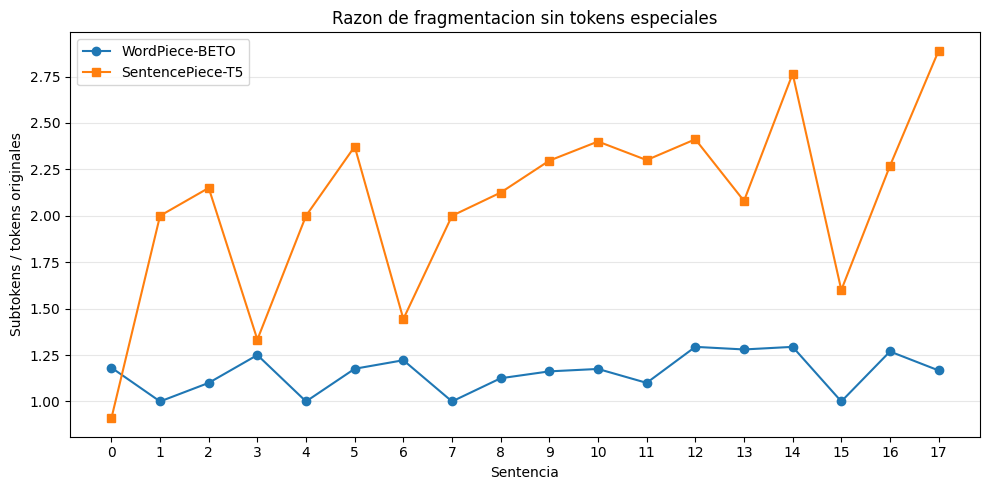

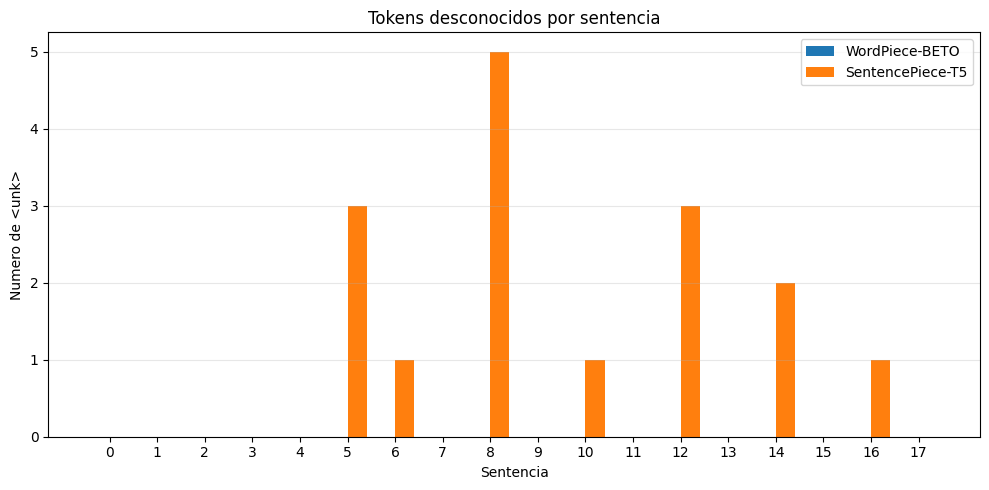

In [39]:
fragmentation_fig_path = FIGURES_DIR / "tokenization_fragmentation_ratios.png"
unknown_fig_path = FIGURES_DIR / "tokenization_unknown_counts.png"

plot_fragmentation_ratios(enriched_df, output_path=fragmentation_fig_path)
plot_unknown_counts(enriched_df, output_path=unknown_fig_path)

fragmentation_fig_path, unknown_fig_path


### Conclusión metodológica

La conclusión debe ser acotada: “En estos ejemplos y con estos tokenizadores concretos, BETO-WordPiece conserva mejor la estructura léxica del español que T5-small SentencePiece.” Evita afirmaciones absolutas como “WordPiece siempre es mejor”.

## Bloque 2: Embeddings distribucionales

Pendiente para una fase posterior. No entrenar Word2Vec ni FastText todavia.

In [40]:
# Ejemplo de uso futuro:
# from src.preprocessing import iter_spanish_billion_sentences, sentence_to_gensim_tokens
# from src.word_embeddings import get_similar_words, get_fasttext_oov_vector
# No entrenar modelos en esta fase.

## Bloque 3: PDFs y embeddings semanticos

Pendiente para una fase posterior. No procesar PDFs ni generar embeddings semanticos todavia.

In [41]:
# Ejemplo de uso futuro:
# from src.pdf_processing import discover_pdf_files, extract_texts_from_pdfs, build_text_splitter
# from src.sentence_embeddings import SENTENCE_EMBEDDING_MODELS, encode_query_and_chunks
# from src.similarity import find_most_similar_chunk
# No generar embeddings en esta fase.